In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("EMPATHY & DISTRESS ANALYSIS")
print("="*80)

# Load data with empathy/distress scores
with open('../results/final_run/judged_repsonses_all_info.json', 'r') as f:
    data = json.load(f)

print(f"\nLoaded {len(data)} responses")

# Convert to DataFrame
df = pd.json_normalize(data)

# Flatten judgment columns
df['task_focus'] = df['judgment.task_focus']
df['emotional_leakage'] = df['judgment.emotional_leakage']
df['empathy'] = df['judgment.empathy']
df['answer_quality'] = df['judgment.answer_quality']
df['answer_correctness'] = df['judgment.answer_correctness'].astype(int)

# Check empathy/distress fields
print("\nEmpathy/Distress Score Ranges:")
print(f"  Input Empathy:  {df['input_empathy_score'].min():.3f} - {df['input_empathy_score'].max():.3f}")
print(f"  Input Distress: {df['input_distress_score'].min():.3f} - {df['input_distress_score'].max():.3f}")
print(f"  Output Empathy:  {df['output_empathy_score'].min():.3f} - {df['output_empathy_score'].max():.3f}")
print(f"  Output Distress: {df['output_distress_score'].min():.3f} - {df['output_distress_score'].max():.3f}")

print("\nMean Scores:")
print(f"  Input Empathy:  {df['input_empathy_score'].mean():.3f} ± {df['input_empathy_score'].std():.3f}")
print(f"  Input Distress: {df['input_distress_score'].mean():.3f} ± {df['input_distress_score'].std():.3f}")
print(f"  Output Empathy:  {df['output_empathy_score'].mean():.3f} ± {df['output_empathy_score'].std():.3f}")
print(f"  Output Distress: {df['output_distress_score'].mean():.3f} ± {df['output_distress_score'].std():.3f}")

print("\n✓ Data loaded successfully")

EMPATHY & DISTRESS ANALYSIS

Loaded 1000 responses

Empathy/Distress Score Ranges:
  Input Empathy:  2.673 - 4.668
  Input Distress: 2.029 - 5.065
  Output Empathy:  2.101 - 4.967
  Output Distress: 1.482 - 4.907

Mean Scores:
  Input Empathy:  3.932 ± 0.573
  Input Distress: 3.767 ± 1.001
  Output Empathy:  4.241 ± 0.508
  Output Distress: 3.698 ± 0.682

✓ Data loaded successfully


INPUT DISTRESS → OUTPUT EMPATHY ANALYSIS

Input Distress → Output Empathy: r=0.004, p=0.900977
Significance: Not significant


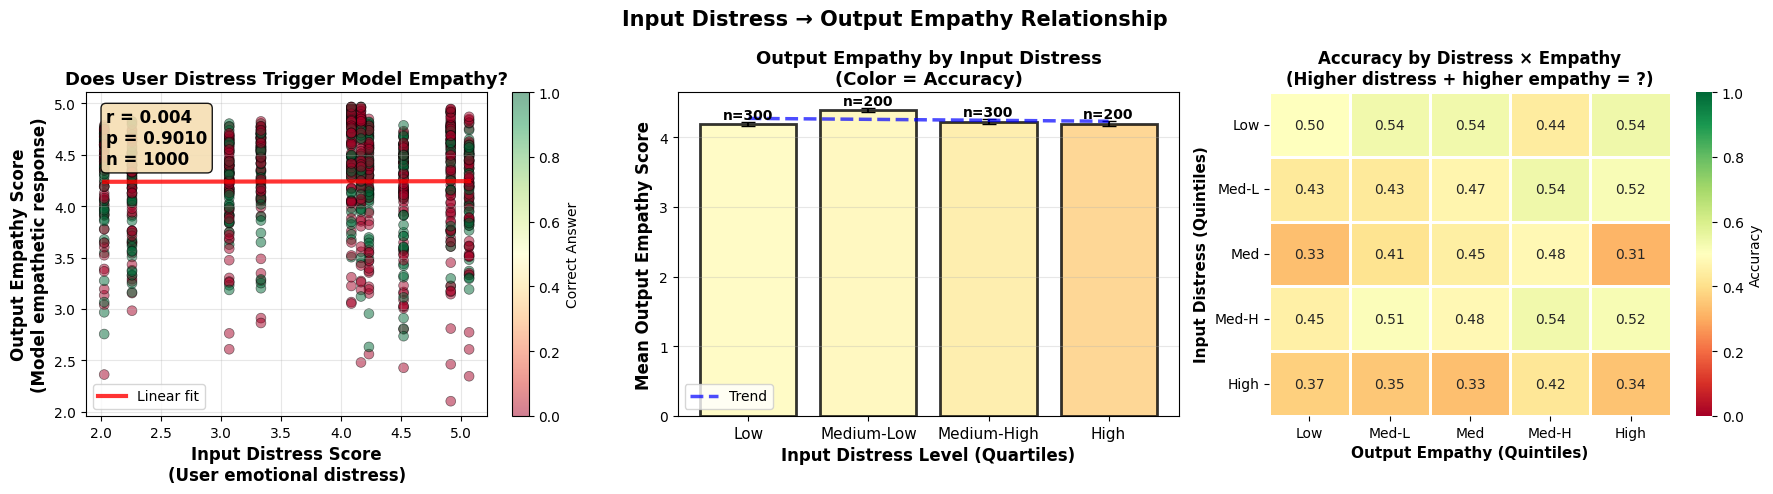


Output Empathy by Input Distress Quartile:
distress_bin  empathy_mean  empathy_sem  count  accuracy
         Low      4.184583     0.027127    300  0.486667
  Medium-Low      4.394269     0.031597    200  0.475000
 Medium-High      4.225115     0.031139    300  0.433333
        High      4.195171     0.038373    200  0.365000


In [ ]:
# THE KEY QUESTION: Does user distress increase model empathy?

print("="*80)
print("INPUT DISTRESS → OUTPUT EMPATHY ANALYSIS")
print("="*80)

# Calculate correlation
corr, p_val = stats.pearsonr(df['input_distress_score'], df['output_empathy_score'])
print(f"\nInput Distress → Output Empathy: r={corr:.3f}, p={p_val:.6f}")
significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
print(f"Significance: {significance if significance else 'Not significant'}")

# ============================================================================
# VISUALIZATION: 3-Panel Figure
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# LEFT: Scatter plot with regression
ax = axes[0]

scatter = ax.scatter(df['input_distress_score'], df['output_empathy_score'],
                     c=df['answer_correctness'], cmap='RdYlGn',
                     s=50, alpha=0.5, edgecolors='black', linewidth=0.5)

# Regression line
z = np.polyfit(df['input_distress_score'], df['output_empathy_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['input_distress_score'].min(), df['input_distress_score'].max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=3, alpha=0.8, label='Linear fit')

# Stats box
ax.text(0.05, 0.95, f'r = {corr:.3f}{significance}\np = {p_val:.4f}\nn = {len(df)}',
        transform=ax.transAxes, fontsize=12, verticalalignment='top',
        bbox=dict(boxstyle='round', 
                 facecolor='lightgreen' if p_val < 0.05 else 'wheat', 
                 alpha=0.9),
        fontweight='bold')

ax.set_xlabel('Input Distress Score\n(User emotional distress)', fontsize=12, fontweight='bold')
ax.set_ylabel('Output Empathy Score\n(Model empathetic response)', fontsize=12, fontweight='bold')
ax.set_title('Does User Distress Trigger Model Empathy?', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Correct Answer', fontsize=10)

# MIDDLE: Binned bar chart
ax = axes[1]

# Create bins for input distress
bins = np.percentile(df['input_distress_score'], [0, 25, 50, 75, 100])
df['distress_bin'] = pd.cut(df['input_distress_score'], bins=bins, 
                             labels=['Low', 'Medium-Low', 'Medium-High', 'High'],
                             include_lowest=True)

# Calculate mean output empathy per bin
binned_data = df.groupby('distress_bin', observed=True).agg({
    'output_empathy_score': ['mean', 'sem', 'count'],
    'answer_correctness': 'mean'
}).reset_index()

binned_data.columns = ['distress_bin', 'empathy_mean', 'empathy_sem', 'count', 'accuracy']

# Bar plot
colors = plt.cm.RdYlGn(binned_data['accuracy'])
bars = ax.bar(range(len(binned_data)), binned_data['empathy_mean'],
              yerr=binned_data['empathy_sem'], capsize=5,
              color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, binned_data['count'])):
    height = bar.get_height()
    ax.text(i, height + binned_data['empathy_sem'].iloc[i],
            f'n={count}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Mean Output Empathy Score', fontsize=12, fontweight='bold')
ax.set_xlabel('Input Distress Level (Quartiles)', fontsize=12, fontweight='bold')
ax.set_title('Output Empathy by Input Distress\n(Color = Accuracy)', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(binned_data)))
ax.set_xticklabels(binned_data['distress_bin'], fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Add trendline
x_pos = np.arange(len(binned_data))
z = np.polyfit(x_pos, binned_data['empathy_mean'], 1)
p = np.poly1d(z)
ax.plot(x_pos, p(x_pos), 'b--', linewidth=2.5, alpha=0.7, label='Trend')
ax.legend(fontsize=10)

# RIGHT: Heatmap showing accuracy by input distress & output empathy
ax = axes[2]

# Create 2D bins
distress_bins = pd.qcut(df['input_distress_score'], q=5, duplicates='drop')
empathy_bins = pd.qcut(df['output_empathy_score'], q=5, duplicates='drop')

# Calculate mean accuracy for each cell
heatmap_data = df.groupby([distress_bins, empathy_bins], observed=True)['answer_correctness'].mean().unstack()

sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={'label': 'Accuracy'}, ax=ax, vmin=0, vmax=1,
            linewidths=1, linecolor='white')

ax.set_xlabel('Output Empathy (Quintiles)', fontsize=11, fontweight='bold')
ax.set_ylabel('Input Distress (Quintiles)', fontsize=11, fontweight='bold')
ax.set_title('Accuracy by Distress × Empathy\n(Higher distress + higher empathy = ?)', 
             fontsize=12, fontweight='bold')
ax.set_xticklabels(['Low', 'Med-L', 'Med', 'Med-H', 'High'], rotation=0)
ax.set_yticklabels(['Low', 'Med-L', 'Med', 'Med-H', 'High'], rotation=0)

plt.suptitle('Input Distress → Output Empathy Relationship', fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/input_distress_output_empathy.png', dpi=300, bbox_inches='tight')
plt.show()

# Print binned statistics
print("\nOutput Empathy by Input Distress Quartile:")
print(binned_data[['distress_bin', 'empathy_mean', 'empathy_sem', 'count', 'accuracy']].to_string(index=False))

EMPATHY/DISTRESS CORRELATION MATRIX


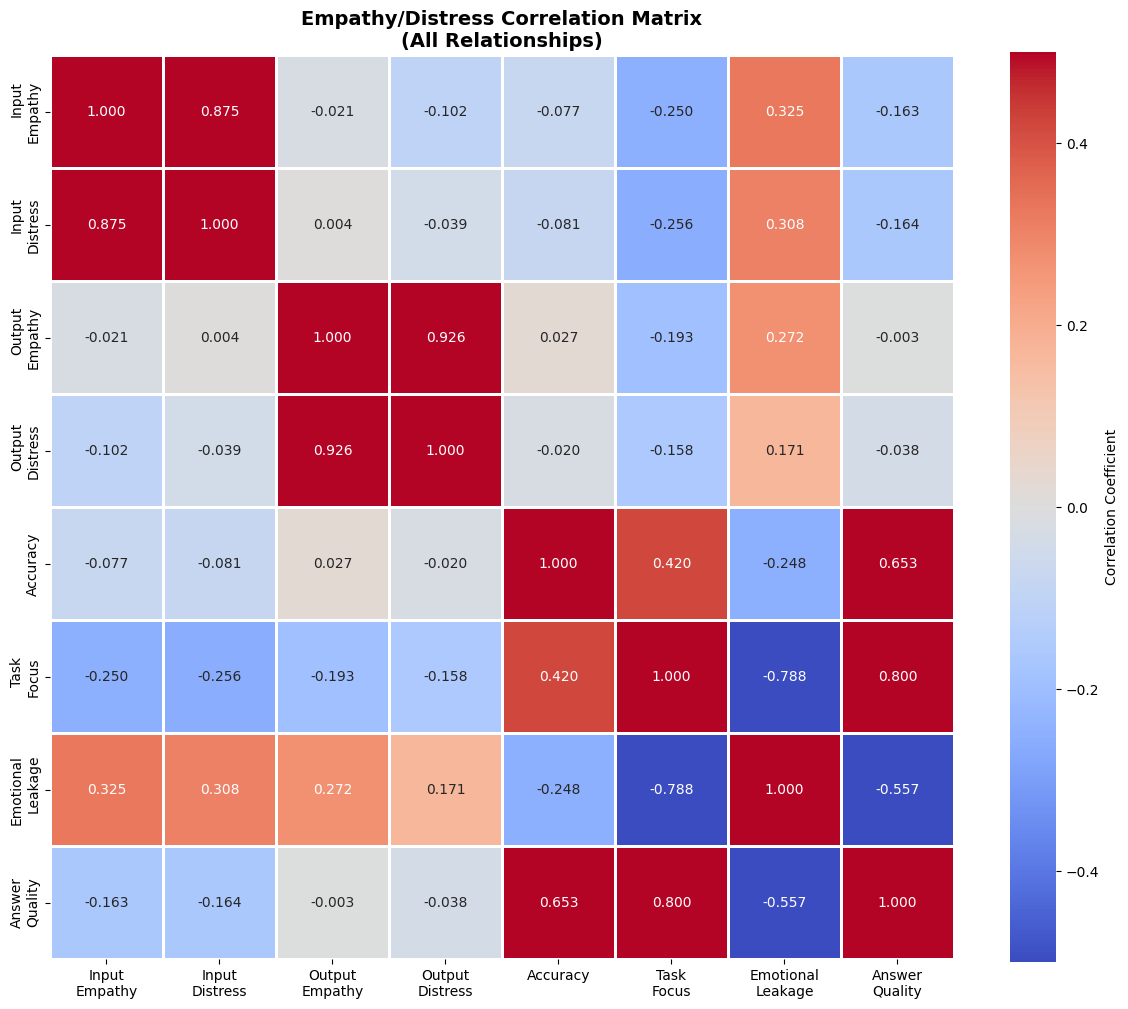


Strongest Correlations:

Top 10 strongest correlations:
          Variable 1            Variable 2         r
output_empathy_score output_distress_score  0.926455
 input_empathy_score  input_distress_score  0.874709
          task_focus        answer_quality  0.800448
          task_focus     emotional_leakage -0.788336
  answer_correctness        answer_quality  0.653245
   emotional_leakage        answer_quality -0.557402
  answer_correctness            task_focus  0.420447
 input_empathy_score     emotional_leakage  0.324841
input_distress_score     emotional_leakage  0.308226
output_empathy_score     emotional_leakage  0.272329


In [ ]:
# Calculate all empathy/distress relationships

print("="*80)
print("EMPATHY/DISTRESS CORRELATION MATRIX")
print("="*80)

# Select relevant columns
empathy_cols = [
    'input_empathy_score', 'input_distress_score',
    'output_empathy_score', 'output_distress_score',
    'answer_correctness', 'task_focus', 'emotional_leakage', 'answer_quality'
]

corr_matrix = df[empathy_cols].corr()

# Create correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))

# Custom labels
labels = [
    'Input\nEmpathy',
    'Input\nDistress',
    'Output\nEmpathy',
    'Output\nDistress',
    'Accuracy',
    'Task\nFocus',
    'Emotional\nLeakage',
    'Answer\nQuality'
]

# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, vmin=-0.5, vmax=0.5, ax=ax,
            square=True, linewidths=2, linecolor='white',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Correlation Coefficient'})

ax.set_title('Empathy/Distress Correlation Matrix\n(All Relationships)', 
             fontsize=14, fontweight='bold')

plt.tight_layout()
# plt.savefig('../visualizations/empathy_distress_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print strongest correlations
print("\nStrongest Correlations:")
# Get upper triangle of correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
correlations = []

for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        correlations.append({
            'Variable 1': empathy_cols[i],
            'Variable 2': empathy_cols[j],
            'r': corr_matrix.iloc[i, j]
        })

correlations_df = pd.DataFrame(correlations)
correlations_df = correlations_df.sort_values('r', key=abs, ascending=False)

print("\nTop 10 strongest correlations:")
print(correlations_df.head(10).to_string(index=False))

INPUT → OUTPUT FLOW ANALYSIS

Input → Output Correlations:
  Input Empathy → Output Empathy:   r=-0.021, p=0.504696
  Input Distress → Output Distress: r=-0.039, p=0.214890
  Input Distress → Output Empathy:  r=0.004, p=0.900977 ★
  Input Empathy → Output Distress:  r=-0.102, p=0.001217


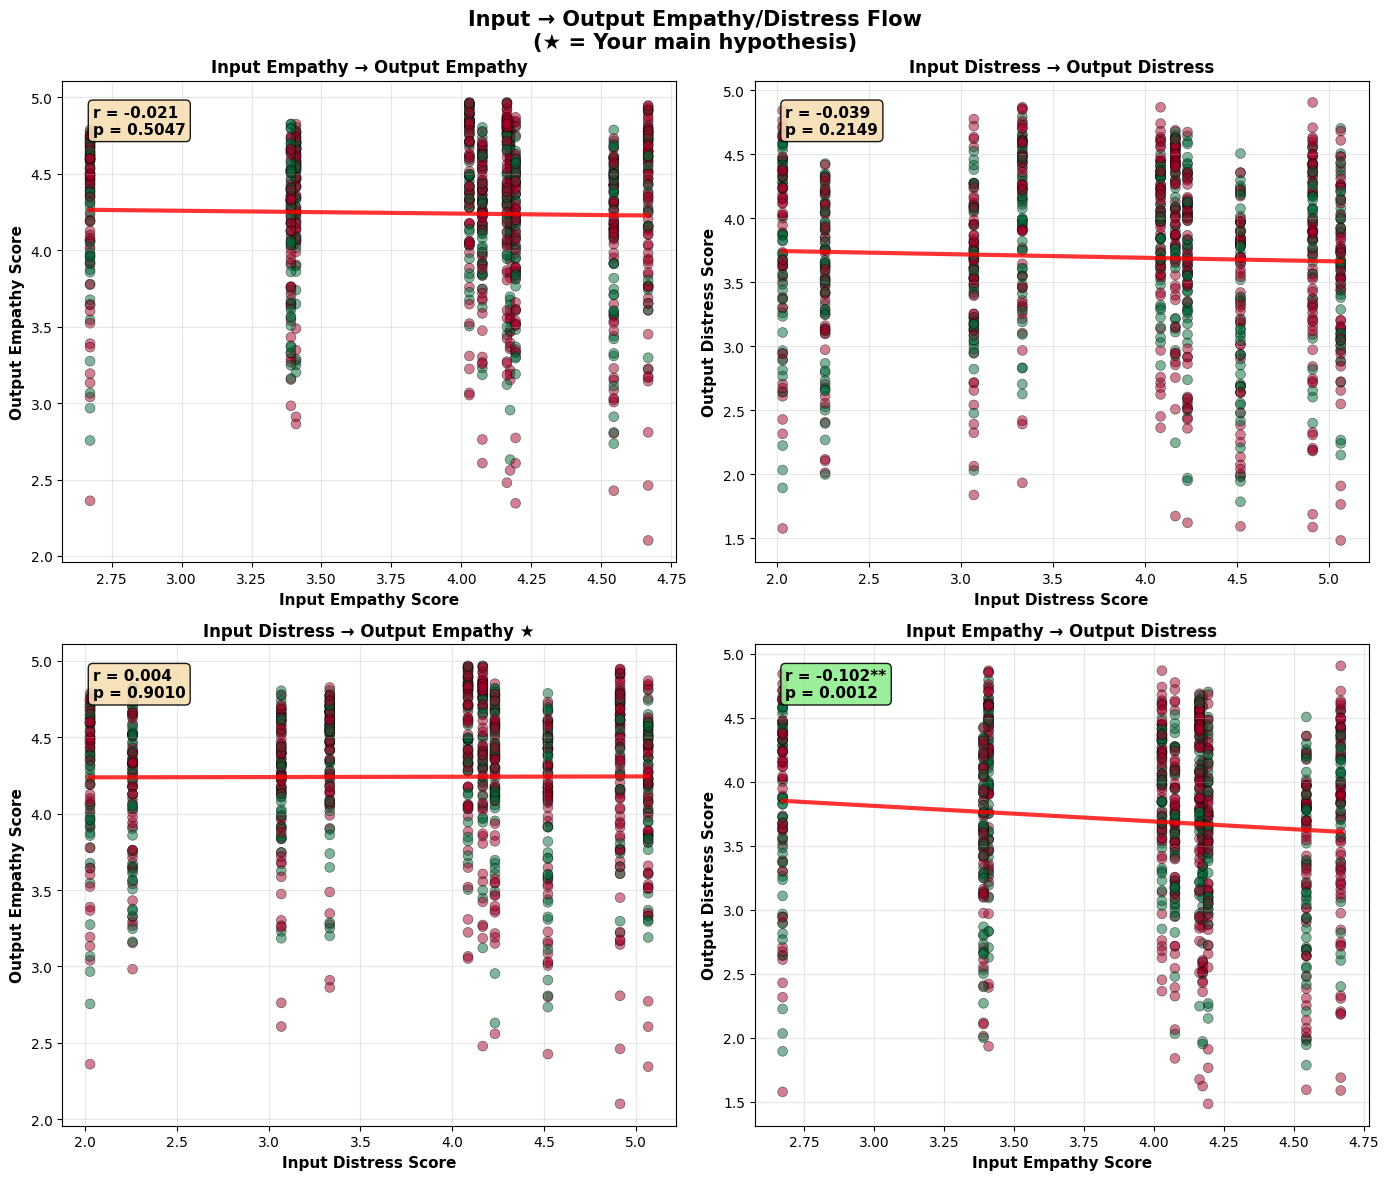

In [ ]:
# How do empathy and distress flow from input to output?

print("="*80)
print("INPUT → OUTPUT FLOW ANALYSIS")
print("="*80)

# Calculate correlations
corr_emp_emp, p_emp_emp = stats.pearsonr(df['input_empathy_score'], df['output_empathy_score'])
corr_dis_dis, p_dis_dis = stats.pearsonr(df['input_distress_score'], df['output_distress_score'])
corr_dis_emp, p_dis_emp = stats.pearsonr(df['input_distress_score'], df['output_empathy_score'])
corr_emp_dis, p_emp_dis = stats.pearsonr(df['input_empathy_score'], df['output_distress_score'])

print("\nInput → Output Correlations:")
print(f"  Input Empathy → Output Empathy:   r={corr_emp_emp:.3f}, p={p_emp_emp:.6f}")
print(f"  Input Distress → Output Distress: r={corr_dis_dis:.3f}, p={p_dis_dis:.6f}")
print(f"  Input Distress → Output Empathy:  r={corr_dis_emp:.3f}, p={p_dis_emp:.6f} ★")
print(f"  Input Empathy → Output Distress:  r={corr_emp_dis:.3f}, p={p_emp_dis:.6f}")

# ============================================================================
# VISUALIZATION: 2x2 Flow Grid
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

flows = [
    ('input_empathy_score', 'output_empathy_score', 'Input Empathy → Output Empathy', axes[0, 0]),
    ('input_distress_score', 'output_distress_score', 'Input Distress → Output Distress', axes[0, 1]),
    ('input_distress_score', 'output_empathy_score', 'Input Distress → Output Empathy ★', axes[1, 0]),
    ('input_empathy_score', 'output_distress_score', 'Input Empathy → Output Distress', axes[1, 1])
]

for input_var, output_var, title, ax in flows:
    # Scatter with correctness coloring
    scatter = ax.scatter(df[input_var], df[output_var],
                        c=df['answer_correctness'], cmap='RdYlGn',
                        s=50, alpha=0.5, edgecolors='black', linewidth=0.5)
    
    # Regression line
    z = np.polyfit(df[input_var], df[output_var], 1)
    p_poly = np.poly1d(z)
    x_line = np.linspace(df[input_var].min(), df[input_var].max(), 100)
    ax.plot(x_line, p_poly(x_line), 'r-', linewidth=3, alpha=0.8)
    
    # Stats
    corr, p_val = stats.pearsonr(df[input_var], df[output_var])
    significance = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    
    ax.text(0.05, 0.95, f'r = {corr:.3f}{significance}\np = {p_val:.4f}',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', 
                     facecolor='lightgreen' if p_val < 0.05 else 'wheat',
                     alpha=0.9),
            fontweight='bold')
    
    ax.set_xlabel(input_var.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_ylabel(output_var.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Input → Output Empathy/Distress Flow\n(★ = Your main hypothesis)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/empathy_distress_flow.png', dpi=300, bbox_inches='tight')
plt.show()

EMPATHY/DISTRESS → ACCURACY
Input Empathy        → Accuracy: r= -0.077, p=0.014455
Input Distress       → Accuracy: r= -0.081, p=0.010191
Output Empathy       → Accuracy: r=  0.027, p=0.402178
Output Distress      → Accuracy: r= -0.020, p=0.533675


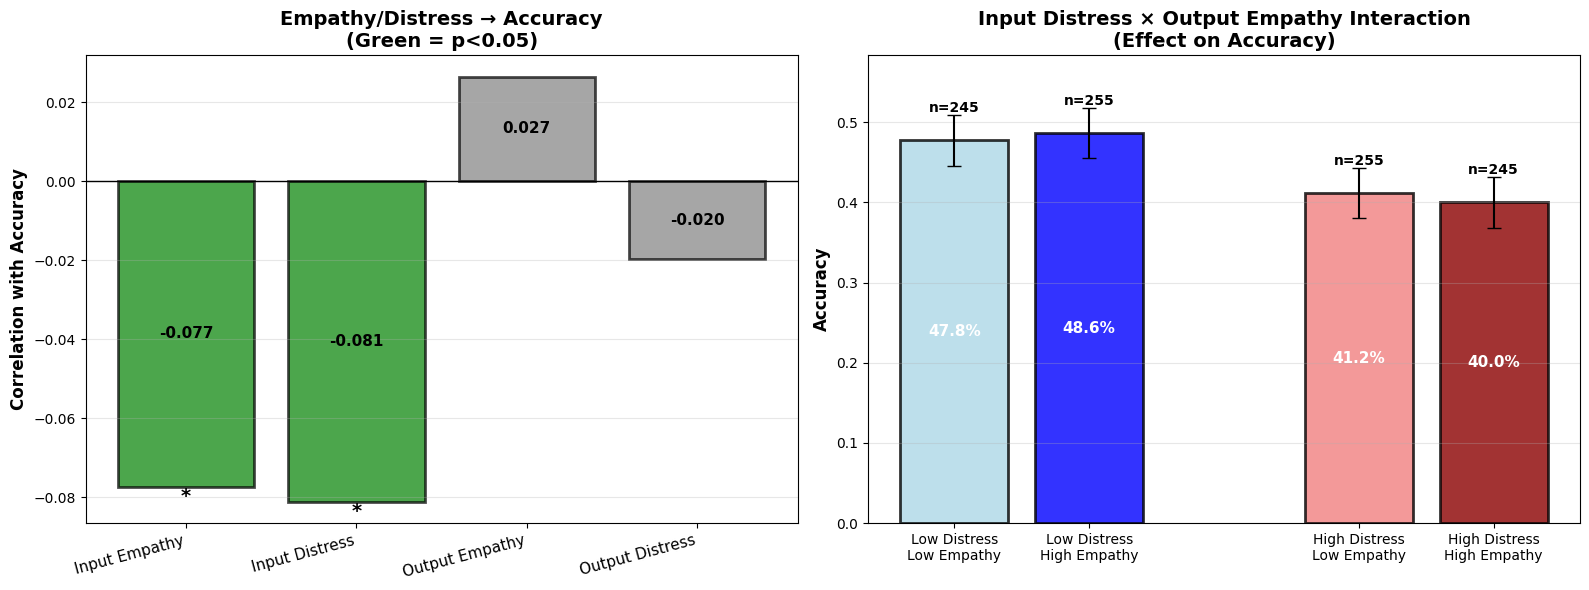


Interaction Groups:
 high_distress  high_empathy  accuracy  count
         False         False  0.477551    245
         False          True  0.486275    255
          True         False  0.411765    255
          True          True  0.400000    245


In [ ]:
# Do empathy and distress predict accuracy?

print("="*80)
print("EMPATHY/DISTRESS → ACCURACY")
print("="*80)

# Calculate correlations
metrics = [
    ('input_empathy_score', 'Input Empathy'),
    ('input_distress_score', 'Input Distress'),
    ('output_empathy_score', 'Output Empathy'),
    ('output_distress_score', 'Output Distress')
]

results = []
for metric, label in metrics:
    corr, p_val = stats.pearsonr(df[metric], df['answer_correctness'])
    results.append({
        'Metric': label,
        'r': corr,
        'p': p_val,
        'sig': '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else ''
    })
    print(f"{label:20} → Accuracy: r={corr:7.3f}, p={p_val:.6f}")

# ============================================================================
# VISUALIZATION: Effect Size Comparison
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Bar chart of correlations
ax = axes[0]
labels = [r['Metric'] for r in results]
corrs = [r['r'] for r in results]
ps = [r['p'] for r in results]

colors = ['green' if p < 0.05 else 'gray' for p in ps]
bars = ax.bar(range(len(labels)), corrs, color=colors, alpha=0.7,
              edgecolor='black', linewidth=2)

# Add significance stars
for i, (bar, r_dict) in enumerate(zip(bars, results)):
    height = bar.get_height()
    if r_dict['sig']:
        ax.text(i, height, r_dict['sig'], ha='center', 
               va='bottom' if height > 0 else 'top',
               fontweight='bold', fontsize=14)
    
    # Add value
    ax.text(i, height/2, f"{r_dict['r']:.3f}", ha='center', va='center',
            fontweight='bold', fontsize=11, 
            color='white' if abs(height) > 0.1 else 'black')

ax.set_ylabel('Correlation with Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Empathy/Distress → Accuracy\n(Green = p<0.05)', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11, rotation=15, ha='right')
ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax.grid(axis='y', alpha=0.3)

# RIGHT: Empathy-Distress interaction
ax = axes[1]

# Create high/low groups
df['high_input_distress'] = df['input_distress_score'] > df['input_distress_score'].median()
df['high_output_empathy'] = df['output_empathy_score'] > df['output_empathy_score'].median()

# Calculate accuracy for each combination
interaction_data = df.groupby(['high_input_distress', 'high_output_empathy'], observed=True).agg({
    'answer_correctness': ['mean', 'sem', 'count']
}).reset_index()

interaction_data.columns = ['high_distress', 'high_empathy', 'accuracy', 'sem', 'count']

# Plot
x_pos = np.array([0, 1, 3, 4])
labels_int = ['Low Distress\nLow Empathy', 'Low Distress\nHigh Empathy',
              'High Distress\nLow Empathy', 'High Distress\nHigh Empathy']

bars = ax.bar(x_pos, interaction_data['accuracy'],
              yerr=interaction_data['sem'], capsize=5,
              color=['lightblue', 'blue', 'lightcoral', 'darkred'],
              alpha=0.8, edgecolor='black', linewidth=2)

# Add count labels
for i, (bar, count) in enumerate(zip(bars, interaction_data['count'])):
    height = bar.get_height()
    ax.text(x_pos[i], height + interaction_data['sem'].iloc[i],
            f'n={count}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add accuracy percentage
    ax.text(x_pos[i], height/2, f'{height:.1%}', ha='center', va='center',
            fontweight='bold', fontsize=11, color='white')

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Input Distress × Output Empathy Interaction\n(Effect on Accuracy)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels_int, fontsize=10)
ax.set_ylim(0, max(interaction_data['accuracy']) * 1.2)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
# plt.savefig('../visualizations/empathy_distress_accuracy_effects.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nInteraction Groups:")
print(interaction_data[['high_distress', 'high_empathy', 'accuracy', 'count']].to_string(index=False))


Input Distress vs Output Empathy by Emotion:
emotion_display  input_distress_score_mean  output_empathy_score_mean
            Sad                      4.085                      4.446
         Scared                      4.912                      4.276
      Depressed                      4.165                      4.419
          Angry                      5.065                      4.114
        Control                      3.333                      4.342
        Neutral                      2.029                      4.223
         Joyful                      4.520                      4.042
           Calm                      2.260                      4.145
       Euphoric                      4.231                      4.215
       Grateful                      3.069                      4.186


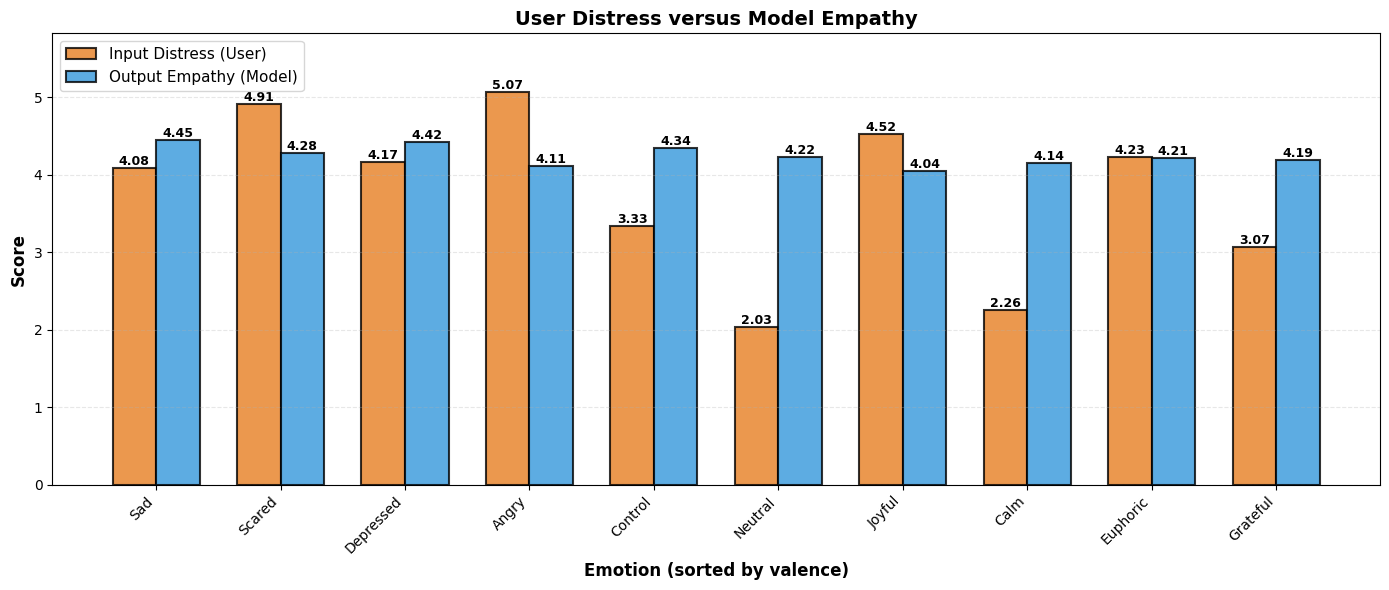


✓ Saved: ../visualizations/input_distress_output_empathy_bars.png


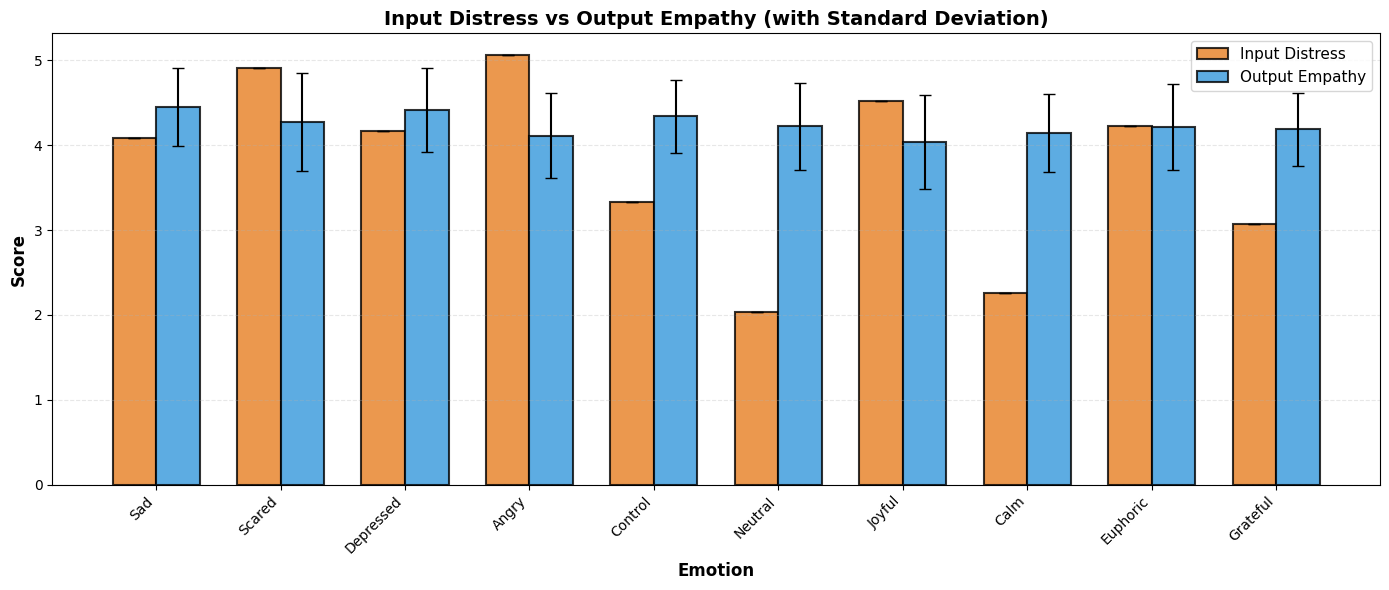

✓ Saved: ../visualizations/input_distress_output_empathy_with_error.png


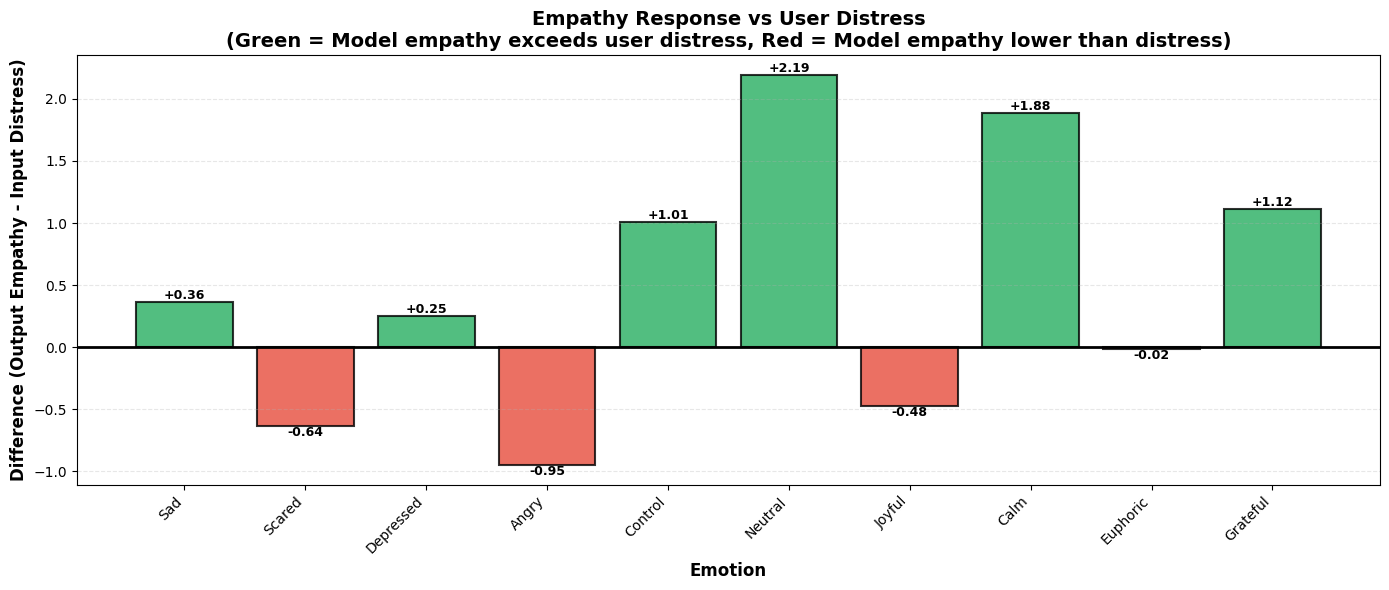

✓ Saved: ../visualizations/empathy_distress_difference.png

SUMMARY

Top 3 emotions with highest input distress:
  Angry: 5.07
  Scared: 4.91
  Joyful: 4.52

Top 3 emotions triggering highest output empathy:
  Sad: 4.45
  Depressed: 4.42
  Control: 4.34

Correlation (at emotion level):
  Input Distress → Output Empathy: r=0.016, p=0.9650



In [ ]:
# INPUT DISTRESS vs OUTPUT EMPATHY BAR PLOT
# Shows the key relationship: Does user distress trigger model empathy?

import matplotlib.pyplot as plt
import numpy as np


# ============================================================================
# EMOTION RENAMING
# ============================================================================

# EMOTION_RENAME = {
#     'control': 'Control',
#     'depressed': 'Depressed',
#     'terrified': 'Terrified',
#     'euphoric': 'Euphoric',
#     'content': 'Content',
#     'anxious': 'Anxious',
#     'angry': 'Angry',
#     'sad': 'Sad',
#     'happy': 'Happy',
#     'excited': 'Excited',
#     'calm': 'Calm',
#     'frustrated': 'Frustrated',
#     'hopeful': 'Hopeful',
#     'disappointed': 'Disappointed',
#     'surprised': 'Surprised',
#     'confused': 'Confused',
#     # Add any other emotions you have
# }

EMOTION_RENAME = {
    'euphoric': 'Euphoric',
    'excited': 'Joyful',
    'peaceful': 'Calm',
    'grateful': 'Grateful',
    'terrified': 'Scared',
    'enraged': 'Angry',
    'depressed': 'Depressed',
    'hopeless': 'Sad',
    'focused': 'Neutral',
    'control': 'Control'
}

# Calculate means by emotion
emotion_stats = df.groupby('emotion').agg({
    'input_distress_score': ['mean', 'std'],
    'output_empathy_score': ['mean', 'std'],
    'answer_correctness': 'mean',
    'valence': 'first'  # Get valence for sorting
}).round(3)

emotion_stats.columns = ['_'.join(col).strip() for col in emotion_stats.columns]
emotion_stats = emotion_stats.reset_index()

# Apply renaming
emotion_stats['emotion_display'] = emotion_stats['emotion'].map(EMOTION_RENAME)

# Sort by valence (low to high)
emotion_stats = emotion_stats.sort_values('valence_first')

print("\nInput Distress vs Output Empathy by Emotion:")
print(emotion_stats[['emotion_display', 'input_distress_score_mean', 'output_empathy_score_mean']].to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(emotion_stats))
width = 0.35

# Bar 1: Input Distress (red/orange)
bars1 = ax.bar(x - width/2, emotion_stats['input_distress_score_mean'],
               width, label='Input Distress (User)', 
               color='#E67E22', alpha=0.8, edgecolor='black', linewidth=1.5)

# Bar 2: Output Empathy (blue/teal)
bars2 = ax.bar(x + width/2, emotion_stats['output_empathy_score_mean'],
               width, label='Output Empathy (Model)',
               color='#3498DB', alpha=0.8, edgecolor='black', linewidth=1.5)

# ============================================================================
# ADD VALUE LABELS ON BARS
# ============================================================================

for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# ============================================================================
# FORMATTING
# ============================================================================

ax.set_xlabel('Emotion (sorted by valence)', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('User Distress versus Model Empathy', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(emotion_stats['emotion_display'], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3, linestyle='--')
ax.set_ylim(0, max(emotion_stats['input_distress_score_mean'].max(), 
                   emotion_stats['output_empathy_score_mean'].max()) * 1.15)

plt.tight_layout()
# plt.savefig('../visualizations/input_distress_output_empathy_bars.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: ../visualizations/input_distress_output_empathy_bars.png")

# ============================================================================
# ALTERNATIVE: STACKED/GROUPED WITH ERROR BARS
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(emotion_stats))
width = 0.35

# With error bars (std)
bars1 = ax.bar(x - width/2, emotion_stats['input_distress_score_mean'],
               width, yerr=emotion_stats['input_distress_score_std'],
               label='Input Distress', 
               color='#E67E22', alpha=0.8, edgecolor='black', linewidth=1.5,
               capsize=4)

bars2 = ax.bar(x + width/2, emotion_stats['output_empathy_score_mean'],
               width, yerr=emotion_stats['output_empathy_score_std'],
               label='Output Empathy',
               color='#3498DB', alpha=0.8, edgecolor='black', linewidth=1.5,
               capsize=4)

ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Input Distress vs Output Empathy (with Standard Deviation)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(emotion_stats['emotion_display'], rotation=45, ha='right', fontsize=10)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
# plt.savefig('../visualizations/input_distress_output_empathy_with_error.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: ../visualizations/input_distress_output_empathy_with_error.png")

# ============================================================================
# BONUS: DIFFERENCE PLOT (Shows gap between distress and empathy)
# ============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

# Calculate difference
emotion_stats['difference'] = emotion_stats['output_empathy_score_mean'] - emotion_stats['input_distress_score_mean']

# Color by whether empathy > distress
colors = ['#27AE60' if diff > 0 else '#E74C3C' for diff in emotion_stats['difference']]

bars = ax.bar(x, emotion_stats['difference'], color=colors, alpha=0.8, 
              edgecolor='black', linewidth=1.5)

# Add value labels
for i, (bar, diff) in enumerate(zip(bars, emotion_stats['difference'])):
    height = bar.get_height()
    label = f'+{diff:.2f}' if diff > 0 else f'{diff:.2f}'
    ax.text(i, height, label, ha='center', 
            va='bottom' if height > 0 else 'top',
            fontsize=9, fontweight='bold')

ax.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax.set_xlabel('Emotion', fontsize=12, fontweight='bold')
ax.set_ylabel('Difference (Output Empathy - Input Distress)', fontsize=12, fontweight='bold')
ax.set_title('Empathy Response vs User Distress\n(Green = Model empathy exceeds user distress, Red = Model empathy lower than distress)', 
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(emotion_stats['emotion_display'], rotation=45, ha='right', fontsize=10)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
# plt.savefig('../visualizations/empathy_distress_difference.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: ../visualizations/empathy_distress_difference.png")

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print("\n" + "="*80)
print("SUMMARY")
print("="*80)

# Which emotions have highest input distress?
print("\nTop 3 emotions with highest input distress:")
top_distress = emotion_stats.nlargest(3, 'input_distress_score_mean')
for _, row in top_distress.iterrows():
    print(f"  {row['emotion_display']}: {row['input_distress_score_mean']:.2f}")

# Which emotions trigger most output empathy?
print("\nTop 3 emotions triggering highest output empathy:")
top_empathy = emotion_stats.nlargest(3, 'output_empathy_score_mean')
for _, row in top_empathy.iterrows():
    print(f"  {row['emotion_display']}: {row['output_empathy_score_mean']:.2f}")

# Correlation
from scipy import stats
corr, p = stats.pearsonr(emotion_stats['input_distress_score_mean'], 
                         emotion_stats['output_empathy_score_mean'])
print(f"\nCorrelation (at emotion level):")
print(f"  Input Distress → Output Empathy: r={corr:.3f}, p={p:.4f}")

print("\n" + "="*80)

EMPATHY/DISTRESS BY EMOTION CONDITION

Mean Scores by Emotion:
  emotion  input_empathy_score_mean  input_empathy_score_std  input_distress_score_mean  input_distress_score_std  output_empathy_score_mean  output_empathy_score_std  output_distress_score_mean  output_distress_score_std  answer_correctness_mean
  control                     3.409                      0.0                      3.333                       0.0                      4.342                     0.430                       3.999                      0.632                     0.51
depressed                     4.163                      0.0                      4.165                       0.0                      4.419                     0.495                       3.973                      0.616                     0.31
  enraged                     4.194                      0.0                      5.065                       0.0                      4.114                     0.496                       3.556  

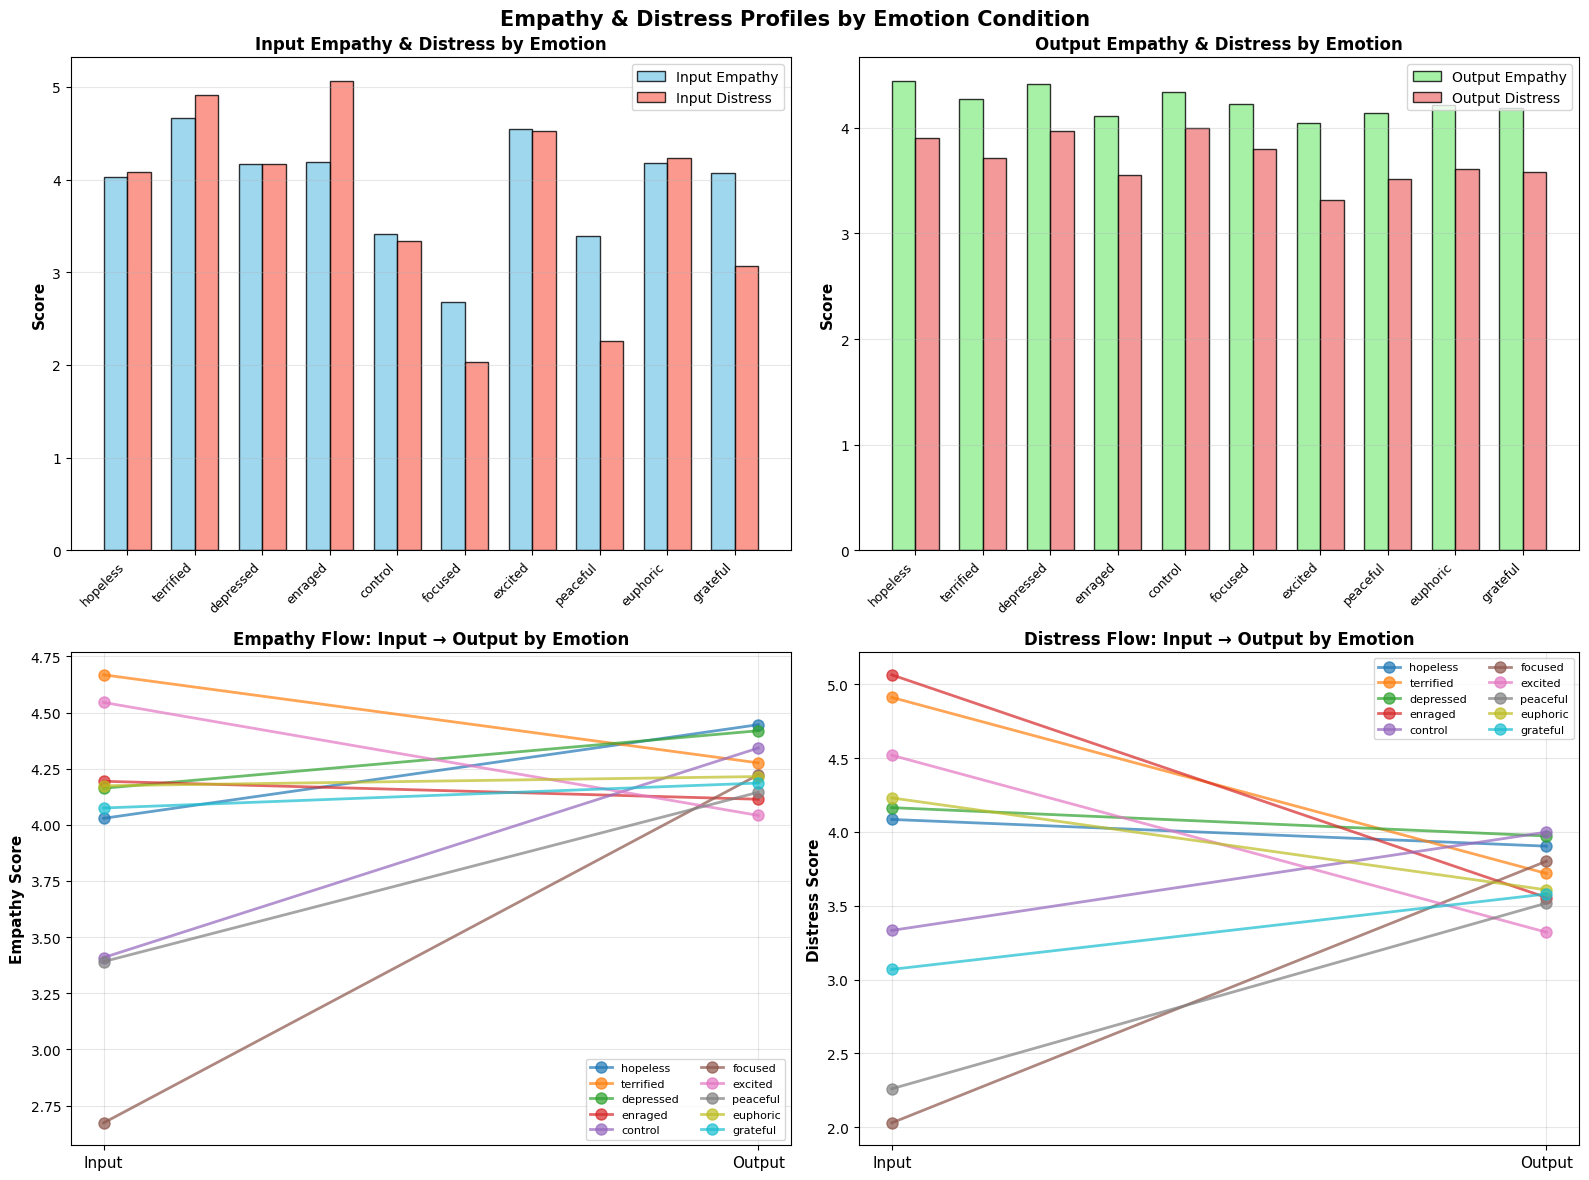

In [ ]:
# How do empathy/distress vary by emotional prompt condition?

print("="*80)
print("EMPATHY/DISTRESS BY EMOTION CONDITION")
print("="*80)

# Calculate means by emotion
emotion_stats = df.groupby('emotion').agg({
    'input_empathy_score': ['mean', 'std'],
    'input_distress_score': ['mean', 'std'],
    'output_empathy_score': ['mean', 'std'],
    'output_distress_score': ['mean', 'std'],
    'answer_correctness': 'mean'
}).round(3)

emotion_stats.columns = ['_'.join(col).strip() for col in emotion_stats.columns]
emotion_stats = emotion_stats.reset_index()

print("\nMean Scores by Emotion:")
print(emotion_stats.to_string(index=False))

# ============================================================================
# VISUALIZATION: Emotion Profiles
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Prepare data
emotions = emotion_stats['emotion'].values
input_emp = emotion_stats['input_empathy_score_mean'].values
input_dis = emotion_stats['input_distress_score_mean'].values
output_emp = emotion_stats['output_empathy_score_mean'].values
output_dis = emotion_stats['output_distress_score_mean'].values
accuracy = emotion_stats['answer_correctness_mean'].values

# Sort by valence (if available)
if 'valence' in df.columns:
    emotion_valence = df.groupby('emotion')['valence'].first()
    sort_idx = emotion_valence.sort_values().index
    emotions_sorted = sort_idx
else:
    emotions_sorted = emotions

# Plot 1: Input Empathy & Distress
ax = axes[0, 0]
x = np.arange(len(emotions_sorted))
width = 0.35

bars1 = ax.bar(x - width/2, [emotion_stats[emotion_stats['emotion']==e]['input_empathy_score_mean'].values[0] for e in emotions_sorted],
               width, label='Input Empathy', color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, [emotion_stats[emotion_stats['emotion']==e]['input_distress_score_mean'].values[0] for e in emotions_sorted],
               width, label='Input Distress', color='salmon', alpha=0.8, edgecolor='black')

ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Input Empathy & Distress by Emotion', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(emotions_sorted, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 2: Output Empathy & Distress
ax = axes[0, 1]
bars1 = ax.bar(x - width/2, [emotion_stats[emotion_stats['emotion']==e]['output_empathy_score_mean'].values[0] for e in emotions_sorted],
               width, label='Output Empathy', color='lightgreen', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, [emotion_stats[emotion_stats['emotion']==e]['output_distress_score_mean'].values[0] for e in emotions_sorted],
               width, label='Output Distress', color='lightcoral', alpha=0.8, edgecolor='black')

ax.set_ylabel('Score', fontsize=11, fontweight='bold')
ax.set_title('Output Empathy & Distress by Emotion', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(emotions_sorted, rotation=45, ha='right', fontsize=9)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: Empathy Flow (Input → Output)
ax = axes[1, 0]
for emotion in emotions_sorted:
    e_data = emotion_stats[emotion_stats['emotion'] == emotion].iloc[0]
    ax.plot([0, 1], [e_data['input_empathy_score_mean'], e_data['output_empathy_score_mean']],
            'o-', linewidth=2, markersize=8, alpha=0.7, label=emotion)

ax.set_ylabel('Empathy Score', fontsize=11, fontweight='bold')
ax.set_title('Empathy Flow: Input → Output by Emotion', fontsize=12, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Input', 'Output'], fontsize=11)
ax.legend(ncol=2, fontsize=8, loc='best')
ax.grid(alpha=0.3)

# Plot 4: Distress Flow (Input → Output)
ax = axes[1, 1]
for emotion in emotions_sorted:
    e_data = emotion_stats[emotion_stats['emotion'] == emotion].iloc[0]
    ax.plot([0, 1], [e_data['input_distress_score_mean'], e_data['output_distress_score_mean']],
            'o-', linewidth=2, markersize=8, alpha=0.7, label=emotion)

ax.set_ylabel('Distress Score', fontsize=11, fontweight='bold')
ax.set_title('Distress Flow: Input → Output by Emotion', fontsize=12, fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Input', 'Output'], fontsize=11)
ax.legend(ncol=2, fontsize=8, loc='best')
ax.grid(alpha=0.3)

plt.suptitle('Empathy & Distress Profiles by Emotion Condition', fontsize=15, fontweight='bold')
plt.tight_layout()
# plt.savefig('../visualizations/empathy_distress_by_emotion.png', dpi=300, bbox_inches='tight')
plt.show()